In [34]:
import pandas as pd 
import numpy as np 
import scipy as sp 
import sys 
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Results schedules 

In [42]:
all_results = pd.read_csv("../../project_folder/results/gaussians/all_results.csv")

In [43]:
all_results = all_results[all_results["score_type"]=="rl"]
all_results = all_results.drop(columns=["time", "value", "score_type"])

In [47]:
all_results_mean = all_results.groupby(["loc", "num_dims", "sigma", "sigma_min"]).mean()

In [52]:
all_results_mean

mean_value
loc num_dims sigma sigma_min            
1.0 2        0.00  0.0000       0.013333
                   0.0001       0.010000
                   0.0010       0.010000
                   0.0100       0.013333
                   0.1000       0.020000
...                                  ...
2.0 30       0.10  0.0000      38.673333
             0.25  0.0000      81.416667
             0.50  0.0000     121.233333
             0.75  0.0000      82.063333
             1.00  0.0000      82.140000

[100 rows x 1 columns]

In [54]:
all_results_1 = all_results[all_results["loc"]==1]
all_results_2 = all_results[all_results["loc"]==2]

In [56]:
all_results_1.groupby(["loc", "num_dims", "sigma", "sigma_min"]).mean()

mean_value
loc num_dims sigma sigma_min            
1.0 2        0.00  0.0000       0.013333
                   0.0001       0.010000
                   0.0010       0.010000
                   0.0100       0.013333
                   0.1000       0.020000
             0.10  0.0000       0.020000
             0.25  0.0000       0.016667
             0.50  0.0000       0.020000
             0.75  0.0000       0.016667
             1.00  0.0000       0.010000
    5        0.00  0.0000       0.043333
                   0.0001       0.056667
                   0.0010       0.076667
                   0.0100       0.050000
                   0.1000       0.046667
             0.10  0.0000       0.050000
             0.25  0.0000       0.063333
             0.50  0.0000       0.063333
             0.75  0.0000       0.103333
             1.00  0.0000       0.203333
    10       0.00  0.0000       0.180000
                   0.0001       0.173333
                   0.0010       0.116667
                   0.0100       0.156667
                   0.1000       0.106667
             0.10  0.0000       0.126667
             0.25  0.0000       0.173333
             0.50  0.0000       0.176667
             0.75  0.0000       0.120000
             1.00  0.0000       0.210000
    20       0.00  0.0000       0.640000
                   0.0001       0.360000
                   0.0010       0.393333
                   0.0100       0.576667
                   0.1000       0.740000
             0.10  0.0000       0.420000
             0.25  0.0000       0.486667
             0.50  0.0000       1.173333
             0.75  0.0000       0.720000
             1.00  0.0000       0.630000
    30       0.00  0.0000       0.690000
                   0.0001       0.860000
                   0.0010       0.773333
                   0.0100       0.790000
                   0.1000       0.863333
             0.10  0.0000       0.863333
             0.25  0.0000       0.816667
             0.50  0.0000       1.593333
             0.75  0.0000       2.086667
             1.00  0.0000       1.410000

In [64]:
all_results_2.groupby(["loc", "num_dims", "sigma", "sigma_min"]).mean()

mean_value
loc num_dims sigma sigma_min            
2.0 2        0.00  0.0000       0.053333
                   0.0001       0.053333
                   0.0010       0.126667
                   0.0100       0.053333
                   0.1000       0.173333
             0.10  0.0000       0.070000
             0.25  0.0000       0.160000
             0.50  0.0000       0.080000
             0.75  0.0000       0.100000
             1.00  0.0000       0.193333
    5        0.00  0.0000       0.380000
                   0.0001       0.190000
                   0.0010       0.286667
                   0.0100       0.386667
                   0.1000       0.170000
             0.10  0.0000       0.263333
             0.25  0.0000       0.413333
             0.50  0.0000       0.586667
             0.75  0.0000       0.973333
             1.00  0.0000       0.940000
    10       0.00  0.0000       0.806667
                   0.0001       0.883333
                   0.0010       0.670000
                   0.0100       0.870000
                   0.1000       1.316667
             0.10  0.0000       1.420000
             0.25  0.0000       1.326667
             0.50  0.0000       2.730000
             0.75  0.0000       6.930000
             1.00  0.0000       6.786667
    20       0.00  0.0000       6.640000
                   0.0001      10.323333
                   0.0010      11.173333
                   0.0100      10.886667
                   0.1000      14.656667
             0.10  0.0000      12.613333
             0.25  0.0000      17.753333
             0.50  0.0000      39.933333
             0.75  0.0000      43.470000
             1.00  0.0000      48.240000
    30       0.00  0.0000      21.030000
                   0.0001      44.186667
                   0.0010      32.686667
                   0.0100      41.016667
                   0.1000      55.966667
             0.10  0.0000      38.673333
             0.25  0.0000      81.416667
             0.50  0.0000     121.233333
             0.75  0.0000      82.063333
             1.00  0.0000      82.140000

# Results parameters 

In [217]:
all_results_parameters = pd.read_csv("../../project_folder/results/gaussians/sweep_results.csv")

In [218]:
all_results_parameters = all_results_parameters[all_results_parameters["score_type"]=="rl"].drop(columns=["value",
                                                                                                         "time",
                                                                                                         "var_value", 
                                                                                                         "mean_time"])

**Learning rate**

In [219]:
all_results_parameters_lr = all_results_parameters.loc[:, ["num_dims", "lr", "mean_value"]]

In [220]:
all_results_parameters_lr.groupby(["num_dims", "lr"]).mean()

mean_value
num_dims lr                
2        0.0001    0.080333
         0.0010    0.695944
5        0.0001    0.315556
         0.0010    3.440111
10       0.0001    1.086556
         0.0010   10.436278
20       0.0001   13.438556
         0.0010   51.115944
30       0.0001   45.672889
         0.0010  237.885389

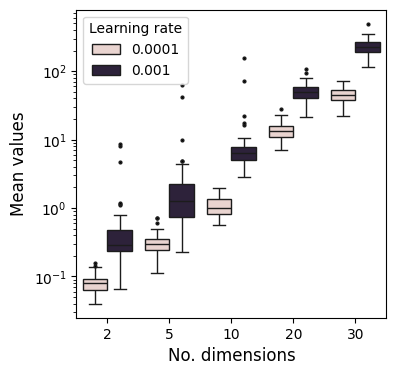

In [233]:
plt.figure(figsize=(4,4))
sns.boxplot(all_results_parameters_lr, x="num_dims", y="mean_value", hue="lr",
            flierprops={"marker": "o", "markerfacecolor": "auto", "markersize": 2})
plt.ylabel("Mean values", fontsize=12)
plt.xlabel("No. dimensions", fontsize=12)
plt.legend(title="Learning rate")
plt.yscale("log")
plt.savefig("../../project_folder/plots/learning_rate_hparams.pdf", format="pdf")
plt.show()

**Time feature dimensions**

In [222]:
all_results_parameters_time_feature_dim = all_results_parameters.loc[:, ["num_dims", "time_feature_dim", "mean_value"]]

In [223]:
all_results_parameters_time_feature_dim.groupby(["num_dims", "time_feature_dim"]).mean()

mean_value
num_dims time_feature_dim            
2        1                   0.302556
         32                  0.437111
         64                  0.266556
         128                 0.546333
5        1                   0.759000
         32                  0.671000
         64                  3.264556
         128                 2.816778
10       1                   3.523778
         32                  3.541444
         64                  3.497778
         128                12.482667
20       1                  35.359222
         32                 29.305000
         64                 29.620444
         128                34.824333
30       1                 125.061778
         32                145.575778
         64                159.635111
         128               136.843889

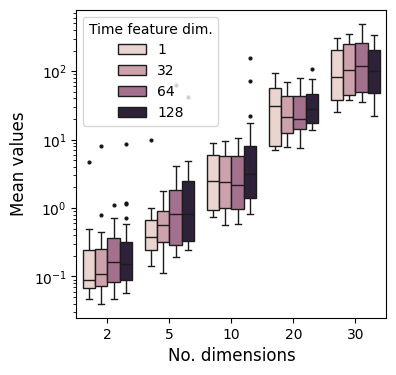

In [224]:
plt.figure(figsize=(4,4))
sns.boxplot(all_results_parameters_time_feature_dim, x="num_dims", y="mean_value", hue="time_feature_dim",
            flierprops={"marker": "o", "markerfacecolor": "auto", "markersize": 2})
plt.ylabel("Mean values", fontsize=12)
plt.xlabel("No. dimensions", fontsize=12)
plt.legend(title="Time feature dim.")
plt.yscale("log")
plt.savefig("../../project_folder/plots/time_feature_dim_hparams.pdf", format="pdf")
plt.show()

**Condition embedding dimensions**

In [225]:
all_results_parameters_cond_latent_dim= all_results_parameters.loc[:, ["num_dims", "cond_latent_dim", "mean_value"]]

In [226]:
all_results_parameters_cond_latent_dim.groupby(["num_dims", "cond_latent_dim"]).mean()

mean_value
num_dims cond_latent_dim            
2        32                 0.406333
         64                 0.384000
         128                0.374083
5        32                 2.480417
         64                 1.830167
         128                1.322917
10       32                 3.630583
         64                 5.410083
         128                8.243583
20       32                31.799583
         64                30.807750
         128               34.224417
30       32               145.689750
         64               139.402583
         128              140.245083

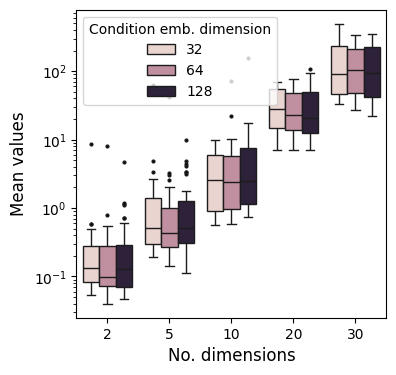

In [227]:
plt.figure(figsize=(4,4))
sns.boxplot(all_results_parameters_cond_latent_dim, x="num_dims", y="mean_value", hue="cond_latent_dim",
            flierprops={"marker": "o", "markerfacecolor": "auto", "markersize": 2})
plt.ylabel("Mean values", fontsize=12)
plt.xlabel("No. dimensions", fontsize=12)
plt.legend(title="Condition emb. dimension")
plt.yscale("log")
plt.savefig("../../project_folder/plots/cond_latent_dim_hparams.pdf", format="pdf")
plt.show()

**Latent dim**

In [230]:
all_results_parameters_latent_dim = all_results_parameters.loc[:, ["num_dims", "latent_dim", "mean_value"]]

In [231]:
all_results_parameters_latent_dim.groupby(["num_dims", "latent_dim"]).mean()

mean_value
num_dims latent_dim            
2        32            0.213194
         64            0.270278
         128           0.191667
         256           0.548750
         512           0.716806
5        32            0.996389
         64            0.871806
         128           1.050417
         256           1.361250
         512           5.109306
10       32            9.574167
         64            3.628056
         128           3.363611
         256           7.086806
         512           5.154444
20       32           31.305972
         64           30.183333
         128          33.629861
         256          33.084167
         512          33.182917
30       32          145.978750
         64          130.960694
         128         130.019583
         256         155.256528
         512         146.680139

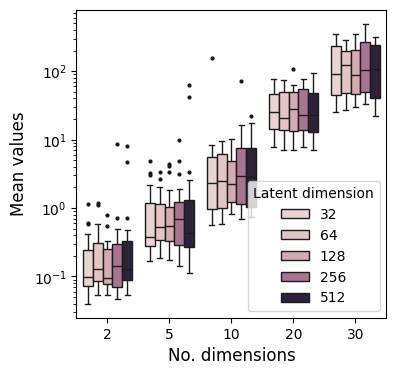

In [232]:
plt.figure(figsize=(4,4))
sns.boxplot(all_results_parameters_latent_dim, x="num_dims", y="mean_value", hue="latent_dim",
            flierprops={"marker": "o", "markerfacecolor": "auto", "markersize": 2})
plt.ylabel("Mean values", fontsize=12)
plt.xlabel("No. dimensions", fontsize=12)
plt.legend(title="Latent dimension")
plt.yscale("log")
plt.savefig("../../project_folder/plots/latent_dim_hparams.pdf", format="pdf")
plt.show()